In [1]:
import glob
import os
import xarray as xa
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.stats import pearsonr
from scipy.ndimage import convolve

import cartopy.crs as ccrs
from cartopy.feature import LAND, COASTLINE
import cmocean.cm as ocm

from subprocess import call
import shutil


In [3]:
#wget https://n5eil01u.ecs.nsidc.org/AMSA/AU_SI12.001/2016.01.01/AMSR_U2_L3_SeaIce12km_B04_20160101.he5
amsr2_dir = 'nsidc'

band_names = [
    'SI_12km_NH_18H_ASC',
    'SI_12km_NH_18V_ASC',
    'SI_12km_NH_23H_ASC',
    'SI_12km_NH_23V_ASC',
    'SI_12km_NH_36H_ASC',
    'SI_12km_NH_36V_ASC',
]

In [13]:
YEAR = 2020
amsr2_file = f'{amsr2_dir}/AMSR_U2_L3_SeaIce12km_B04_{YEAR}0101.he5'
with xa.open_dataset(amsr2_file, group='HDFEOS/GRIDS/NpPolarGrid12km/Data Fields') as ds:
    bands = np.dstack([ds[band_name].to_numpy() for band_name in band_names])
    amsr2_sic = ds['SI_12km_NH_ICECON_ASC'].to_numpy()

with xa.open_dataset(amsr2_file, group='HDFEOS/GRIDS/NpPolarGrid12km') as ds:
    lon = ds.lon.to_numpy()
    lat = ds.lat.to_numpy()



In [31]:
gpi = np.isfinite(bands[:,:,0]) * (amsr2_sic > 15) * (amsr2_sic <= 100)
bands_gpi = bands[gpi, :]

bands_avg = bands_gpi.mean(axis=0)
bands_std = bands_gpi.std(axis=0)
bands_sca = (bands_gpi - bands_avg[None]) / bands_std[None]

(896, 608, 6)

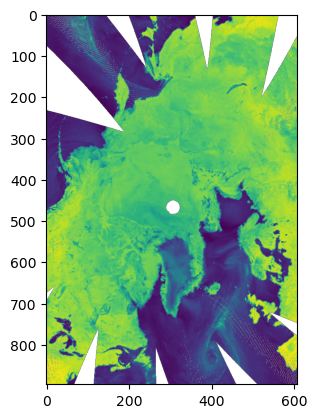

In [32]:
plt.imshow(bands[:,:,0])
bands.shape

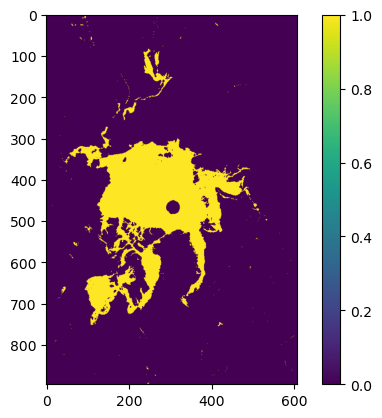

In [33]:
plt.imshow(gpi)
plt.colorbar()

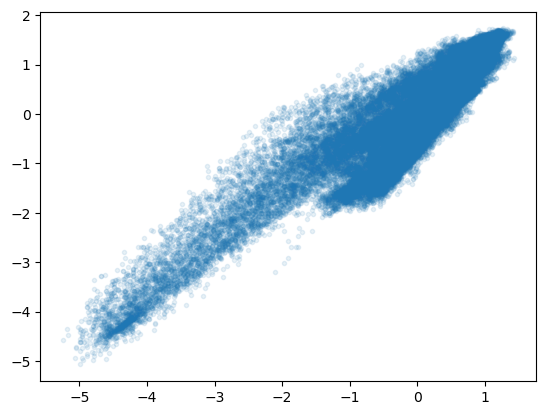

In [34]:
plt.plot(bands_sca[:, 0], bands_sca[:, 1], '.', alpha=0.1)

Number of clusters found: 30
Cluster sizes (first 10): [7159 2105 4000 3402 1991 3480 3186 3093 1631 2500]


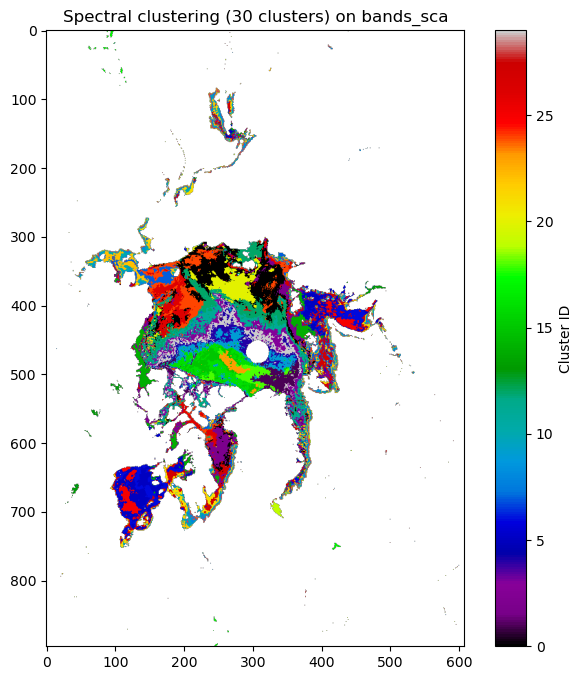

In [35]:
from sklearn.cluster import SpectralClustering

n_clusters = 30

spec = SpectralClustering(
    n_clusters=n_clusters,
    affinity="nearest_neighbors",
    n_neighbors=20,
    assign_labels="kmeans",
    random_state=42,
    n_init=10,
    eigen_solver="lobpcg"
)

cluster_labels = spec.fit_predict(bands_sca)

# map labels back to the original grid (non-ice/non-valid pixels stay -1)
cluster_map = np.full(gpi.shape, -1, dtype=float) + np.nan
cluster_map[gpi] = cluster_labels

print("Number of clusters found:", np.unique(cluster_labels).size)
print("Cluster sizes (first 10):", np.bincount(cluster_labels)[:10])

plt.figure(figsize=(8, 8))
plt.imshow(cluster_map, cmap="nipy_spectral", vmin=0, vmax=n_clusters - 1)
plt.colorbar(label="Cluster ID")
plt.title(f"Spectral clustering ({n_clusters} clusters) on bands_sca")
plt.show()

In [36]:
cgrid, rgrid = np.meshgrid(np.arange(cluster_map.shape[1]), np.arange(cluster_map.shape[0]))
bands_gpi = np.dstack([bands, cgrid[:,:,None], rgrid[:,:,None]])[gpi, :]
bands_avg = bands_gpi.mean(axis=0)
bands_std = bands_gpi.std(axis=0)
bands_sca = (bands_gpi - bands_avg[None]) / bands_std[None]

/opt/miniconda3/envs/ice/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Number of clusters found: 30
Cluster sizes (first 10): [2659 4681 4485 2833 4332 1307 6637 4729 3850  131]


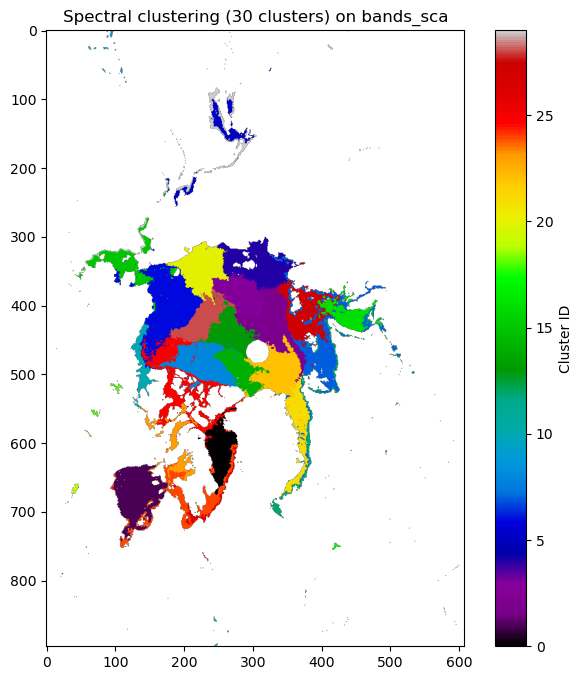

In [37]:
from sklearn.cluster import SpectralClustering

n_clusters = 30

spec = SpectralClustering(
    n_clusters=n_clusters,
    affinity="nearest_neighbors",
    n_neighbors=20,
    assign_labels="kmeans",
    random_state=42,
    n_init=10,
    eigen_solver="lobpcg"
)

cluster_labels = spec.fit_predict(bands_sca)

# map labels back to the original grid (non-ice/non-valid pixels stay -1)
cluster_map = np.full(gpi.shape, -1, dtype=float) + np.nan
cluster_map[gpi] = cluster_labels

print("Number of clusters found:", np.unique(cluster_labels).size)
print("Cluster sizes (first 10):", np.bincount(cluster_labels)[:10])

plt.figure(figsize=(8, 8))
plt.imshow(cluster_map, cmap="nipy_spectral", vmin=0, vmax=n_clusters - 1)
plt.colorbar(label="Cluster ID")
plt.title(f"Spectral clustering ({n_clusters} clusters) on bands_sca")
plt.show()